## 1. Introduction

This notebook builds classical machine-learning models to detect **pneumonia** from chest X-ray images.
The goal is to provide a reproducible benchmark pipeline that can support clinical triage (decision support), not replace medical judgment.

The assignment constraints are explicitly addressed:
- Train-validation-test workflow
- Cross-validation workflow
- Comparison against a simple train/test split
- Hyperparameter tuning using one dataset (the official validation split)
- Comparison of at least three algorithms
- Metrics and visualizations (including ROC-AUC)
- Saving trained models to disk

### 1.1 Requirements and Dependencies

Python libraries used:
- `numpy`, `pandas`
- `matplotlib`, `seaborn`
- `Pillow`
- `scikit-learn`
- `joblib`

Dataset location expected:
- `datasets/chest_xray/train`
- `datasets/chest_xray/val`
- `datasets/chest_xray/test`

## 2. Research Questions

1. **Which classical ML algorithm performs best on this dataset after consistent preprocessing?**
2. **Does cross-validation estimate performance more reliably than a single simple split?**
3. **How much does validation-based tuning improve final test ROC-AUC and F1-score?**

We will answer these three questions explicitly in the final section with evidence from tables and plots.

## 3. Dataset Loading and Exploration

### 3.1 Imports

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import ParameterGrid, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
RANDOM_STATE = 42

### 3.2 Define Dataset Paths

In [2]:
DATASET_PATH = Path("datasets/chest_xray")
TRAIN_PATH = DATASET_PATH / "train"
VAL_PATH = DATASET_PATH / "val"
TEST_PATH = DATASET_PATH / "test"

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    print(p, "exists:", p.exists())

datasets/chest_xray/train exists: True
datasets/chest_xray/val exists: True
datasets/chest_xray/test exists: True


### 3.3 Count Images per Class

In [3]:
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
CLASS_TO_LABEL = {"NORMAL": 0, "PNEUMONIA": 1}

def count_images(split_path: Path):
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = split_path / class_name
        counts[class_name] = len(list(class_dir.glob("*"))) if class_dir.exists() else 0
    return counts

train_counts = count_images(TRAIN_PATH)
val_counts = count_images(VAL_PATH)
test_counts = count_images(TEST_PATH)

print("Train distribution:", train_counts)
print("Validation distribution:", val_counts)
print("Test distribution:", test_counts)

Train distribution: {'NORMAL': 1342, 'PNEUMONIA': 3876}
Validation distribution: {'NORMAL': 9, 'PNEUMONIA': 9}
Test distribution: {'NORMAL': 234, 'PNEUMONIA': 390}


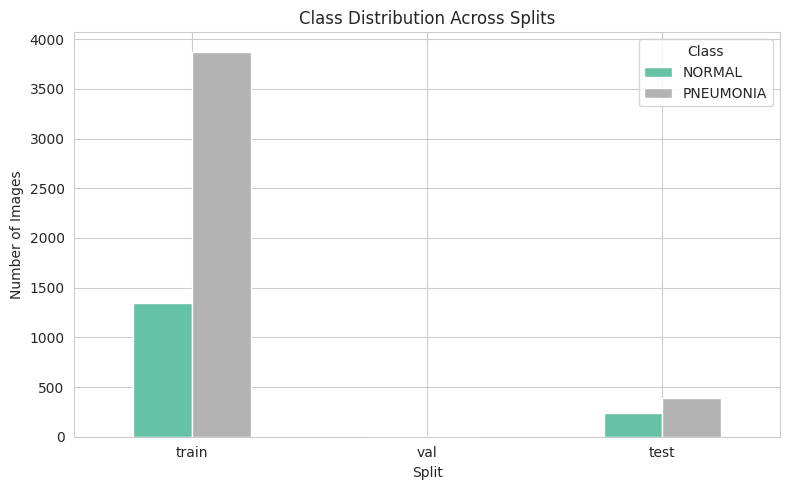

,NORMAL,PNEUMONIA
train,1342,3876
val,9,9
test,234,390


In [4]:
df_distribution = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts,
}).T

ax = df_distribution.plot(kind="bar", figsize=(8, 5), colormap="Set2")
ax.set_title("Class Distribution Across Splits")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Images")
ax.legend(title="Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df_distribution

The distribution is imbalanced toward the `PNEUMONIA` class. This influences metric choice: we report not only accuracy, but also F1 and ROC-AUC.

### 3.4 Inspect Sample Images

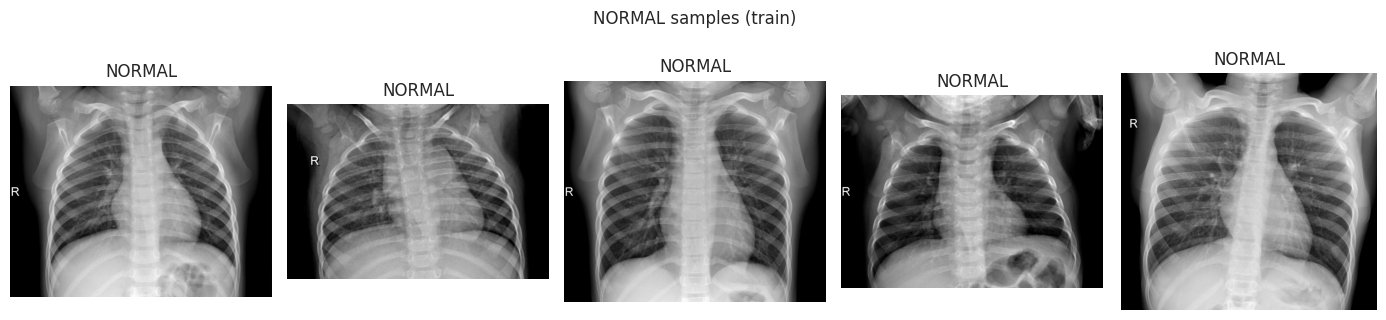

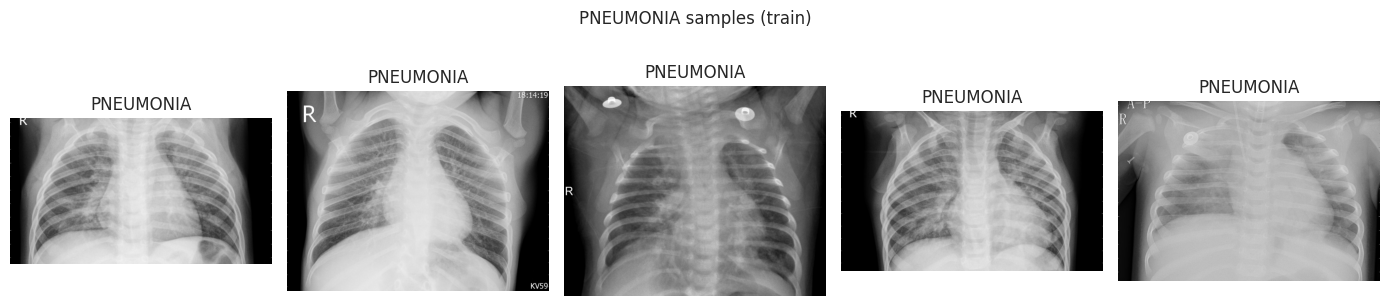

In [5]:
def show_samples(split_path: Path, class_name: str, n: int = 5):
    image_paths = list((split_path / class_name).glob("*"))[:n]
    plt.figure(figsize=(14, 3))
    for i, img_path in enumerate(image_paths):
        with Image.open(img_path) as img:
            plt.subplot(1, n, i + 1)
            plt.imshow(img, cmap="gray")
            plt.title(class_name)
            plt.axis("off")
    plt.suptitle(f"{class_name} samples ({split_path.name})", y=1.05)
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_PATH, "NORMAL", n=5)
show_samples(TRAIN_PATH, "PNEUMONIA", n=5)

Image size: (1982, 1603)
Image mode: L


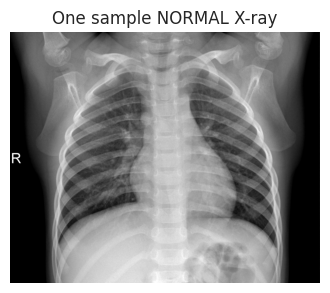

In [6]:
sample_image_path = next((TRAIN_PATH / "NORMAL").glob("*"))
with Image.open(sample_image_path) as image:
    print("Image size:", image.size)
    print("Image mode:", image.mode)
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")
    plt.title("One sample NORMAL X-ray")
    plt.axis("off")
    plt.show()

## 4. Preprocessing Pipeline

To make images usable for classical ML estimators, we apply the following steps:
1. Convert to grayscale (`L` mode)
2. Resize to a fixed shape (`64x64`)
3. Normalize pixel intensities to `[0, 1]`
4. Flatten image matrix into a 1D feature vector

For some models, scaling and PCA are added inside scikit-learn pipelines.

In [7]:
IMG_SIZE = (64, 64)
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def build_split_dataframe(split_path: Path, split_name: str) -> pd.DataFrame:
    rows = []
    for class_name in CLASS_NAMES:
        class_dir = split_path / class_name
        for image_path in class_dir.glob("*"):
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            rows.append(
                {
                    "split": split_name,
                    "class_name": class_name,
                    "label": CLASS_TO_LABEL[class_name],
                    "path": image_path,
                }
            )
    return pd.DataFrame(rows)

def load_image_as_vector(path: Path, image_size=IMG_SIZE) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("L").resize(image_size)
        arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr.flatten()

def build_feature_matrix(df: pd.DataFrame):
    vectors = []
    labels = []
    skipped = 0
    for path, label in tqdm(zip(df["path"], df["label"]), total=len(df), desc="Loading images"):
        try:
            vectors.append(load_image_as_vector(path))
            labels.append(label)
        except Exception:
            skipped += 1
    if skipped:
        print(f"Skipped unreadable files: {skipped}")
    X = np.vstack(vectors)
    y = np.asarray(labels, dtype=np.int64)
    return X, y

In [8]:
df_train = build_split_dataframe(TRAIN_PATH, "train")
df_val = build_split_dataframe(VAL_PATH, "val")
df_test = build_split_dataframe(TEST_PATH, "test")

print(df_train.shape, df_val.shape, df_test.shape)
display(df_train.head())

(5216, 4) (16, 4) (624, 4)


,split,class_name,label,path
0,train,NORMAL,0,datasets/chest_xray/train/NORMAL/NORMAL2-IM-11...
1,train,NORMAL,0,datasets/chest_xray/train/NORMAL/IM-0304-0001....
2,train,NORMAL,0,datasets/chest_xray/train/NORMAL/NORMAL2-IM-11...
3,train,NORMAL,0,datasets/chest_xray/train/NORMAL/NORMAL2-IM-04...
4,train,NORMAL,0,datasets/chest_xray/train/NORMAL/NORMAL2-IM-11...


In [9]:
X_train, y_train = build_feature_matrix(df_train)
X_val, y_val = build_feature_matrix(df_val)
X_test, y_test = build_feature_matrix(df_test)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Loading images:   0%|                                  | 0/5216 [00:00<?, ?it/s]

Loading images:   0%|                          | 7/5216 [00:00<01:17, 66.86it/s]

Loading images:   0%|                         | 15/5216 [00:00<01:12, 71.38it/s]

Loading images:   0%|                         | 23/5216 [00:00<01:09, 74.63it/s]

Loading images:   1%|▏                        | 32/5216 [00:00<01:05, 79.03it/s]

...

Loading images:  87%|████████████████████▉   | 543/624 [00:03<00:00, 231.79it/s]

Loading images:  92%|█████████████████████▉  | 571/624 [00:03<00:00, 240.60it/s]

Loading images:  96%|███████████████████████ | 599/624 [00:04<00:00, 250.35it/s]

Loading images: 100%|████████████████████████| 624/624 [00:04<00:00, 152.20it/s]

X_train: (5216, 4096) y_train: (5216,)
X_val: (16, 4096) y_val: (16,)
X_test: (624, 4096) y_test: (624,)


## 5. Algorithms

We compare three algorithms:
- Logistic Regression + Standardization + PCA
- K-Nearest Neighbors + Standardization + PCA
- Random Forest (tree-based baseline)

This gives a mix of linear, distance-based, and ensemble methods.

In [10]:
model_zoo = {
    "logreg_pca": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1200, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "knn_pca": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("clf", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "random_forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
}

list(model_zoo.keys())

['logreg_pca', 'knn_pca', 'random_forest']

## 6. Simple Train/Test Split Baseline

This section intentionally uses one simple random split (no cross-validation) to provide a baseline comparison requested in the subject.

In [11]:
X_pool = np.vstack([X_train, X_val])
y_pool = np.concatenate([y_train, y_val])

X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_pool,
    y_pool,
    test_size=0.2,
    stratify=y_pool,
    random_state=RANDOM_STATE,
)

def evaluate_binary_model(model, X_fit, y_fit, X_eval, y_eval):
    model = clone(model)
    model.fit(X_fit, y_fit)
    y_pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.decision_function(X_eval)

    return {
        "model": model,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred),
        "recall": recall_score(y_eval, y_pred),
        "f1": f1_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_score),
    }

simple_results = []
for name, model in model_zoo.items():
    result = evaluate_binary_model(model, X_simple_train, y_simple_train, X_simple_test, y_simple_test)
    result["name"] = name
    simple_results.append(result)

df_simple = pd.DataFrame(simple_results)[["name", "accuracy", "precision", "recall", "f1", "roc_auc"]].sort_values("roc_auc", ascending=False)
df_simple

,name,accuracy,precision,recall,f1,roc_auc
2,random_forest,0.946514,0.947826,0.981982,0.964602,0.987859
0,logreg_pca,0.946514,0.971242,0.956242,0.963684,0.981298
1,knn_pca,0.945559,0.944444,0.984556,0.964083,0.968087


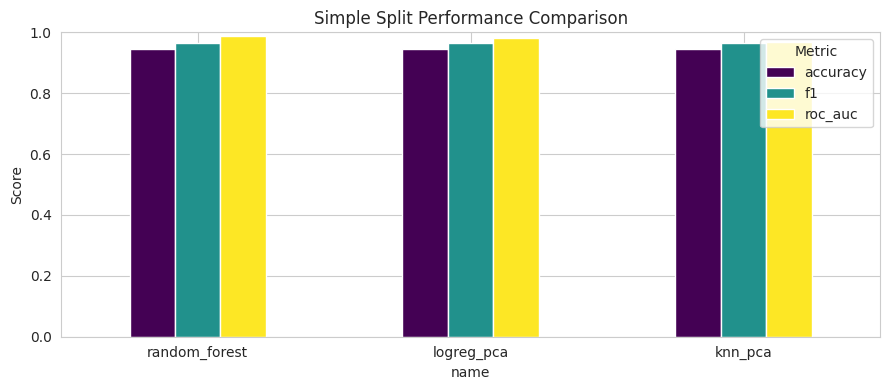

In [12]:
ax = df_simple.set_index("name")[["accuracy", "f1", "roc_auc"]].plot(kind="bar", figsize=(9, 4), colormap="viridis")
ax.set_title("Simple Split Performance Comparison")
ax.set_ylabel("Score")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

## 7. Cross-Validation Procedure

We run stratified 5-fold CV on the official training split to estimate generalization with lower variance than a single random split.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

cv_rows = []
for name, model in model_zoo.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append(
        {
            "name": name,
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "f1_mean": scores["test_f1"].mean(),
            "f1_std": scores["test_f1"].std(),
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
        }
    )

df_cv = pd.DataFrame(cv_rows).sort_values("roc_auc_mean", ascending=False)
df_cv

,name,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,random_forest,0.944593,0.004830,0.963494,0.003209,0.986299,0.002465
0,logreg_pca,0.945552,0.003559,0.963150,0.002483,0.984319,0.003144
1,knn_pca,0.945360,0.007977,0.963790,0.005293,0.972109,0.009302


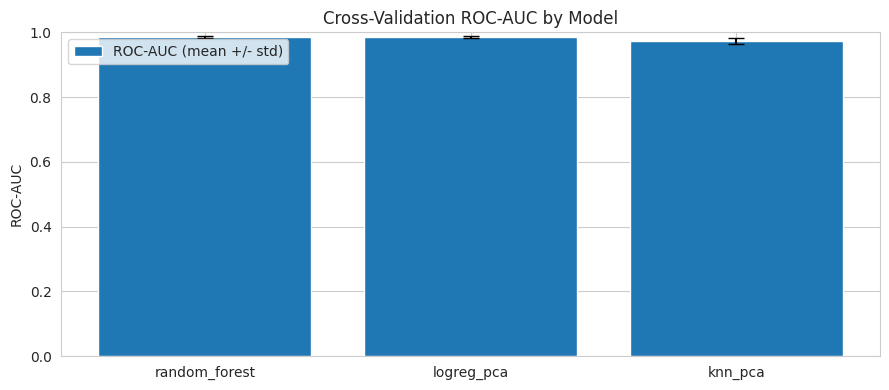

In [14]:
plt.figure(figsize=(9, 4))
plt.bar(df_cv["name"], df_cv["roc_auc_mean"], yerr=df_cv["roc_auc_std"], capsize=6, label="ROC-AUC (mean +/- std)")
plt.title("Cross-Validation ROC-AUC by Model")
plt.ylabel("ROC-AUC")
plt.ylim(0.0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning on Validation Set

Requirement coverage: we tune each algorithm using the **official validation split** (train -> fit, val -> select params).

In [15]:
param_grids = {
    "logreg_pca": {
        "clf__C": [0.3, 1.0],
    },
    "knn_pca": {
        "clf__n_neighbors": [5, 9],
    },
    "random_forest": {
        "clf__n_estimators": [120],
        "clf__max_depth": [None, 20],
    },
}

def tune_with_validation(model_name, base_model, grid, X_tr, y_tr, X_va, y_va):
    rows = []
    best_score = -np.inf
    best_model = None
    best_params = None

    for params in ParameterGrid(grid):
        model = clone(base_model).set_params(**params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        y_prob = model.predict_proba(X_va)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_va)

        row = {
            "name": model_name,
            "params": params,
            "f1": f1_score(y_va, y_pred),
            "roc_auc": roc_auc_score(y_va, y_prob),
        }
        rows.append(row)

        if row["roc_auc"] > best_score:
            best_score = row["roc_auc"]
            best_model = model
            best_params = params

    return best_model, best_params, pd.DataFrame(rows).sort_values("roc_auc", ascending=False)

tuned_models = {}
tuning_tables = {}

for name, model in model_zoo.items():
    best_model, best_params, table = tune_with_validation(
        name, model, param_grids[name], X_train, y_train, X_val, y_val
    )
    tuned_models[name] = best_model
    tuning_tables[name] = table
    print(f"{name} best params: {best_params}")

df_tuning_best = pd.DataFrame(
    [
        {
            "name": name,
            "best_val_f1": tuning_tables[name].iloc[0]["f1"],
            "best_val_roc_auc": tuning_tables[name].iloc[0]["roc_auc"],
        }
        for name in tuning_tables
    ]
).sort_values("best_val_roc_auc", ascending=False)

df_tuning_best

logreg_pca best params: {'clf__C': 0.3}


knn_pca best params: {'clf__n_neighbors': 9}


random_forest best params: {'clf__max_depth': None, 'clf__n_estimators': 120}


,name,best_val_f1,best_val_roc_auc
2,random_forest,0.695652,1.000000
1,knn_pca,0.666667,0.984375
0,logreg_pca,0.842105,0.968750


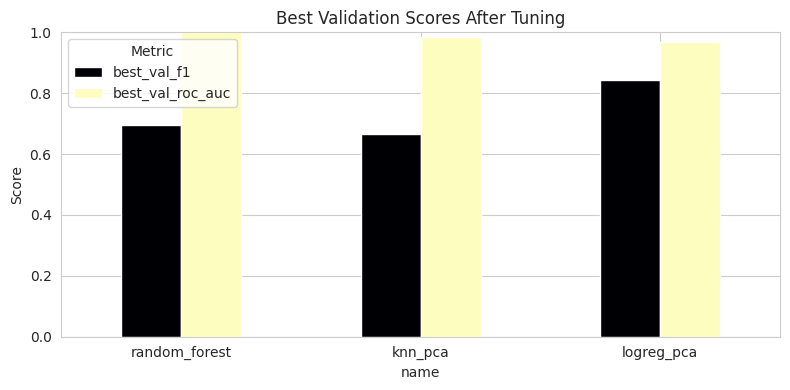

In [16]:
ax = df_tuning_best.set_index("name")[["best_val_f1", "best_val_roc_auc"]].plot(kind="bar", figsize=(8, 4), colormap="magma")
ax.set_title("Best Validation Scores After Tuning")
ax.set_ylabel("Score")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

## 9. Final Test Evaluation

To keep test evaluation honest, we only evaluate tuned models once on the untouched official test split.

In [17]:
test_rows = []
test_outputs = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    metrics = {
        "name": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    test_rows.append(metrics)
    test_outputs[name] = {"y_pred": y_pred, "y_prob": y_prob}

df_test_results = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False)
df_test_results

,name,accuracy,precision,recall,f1,roc_auc
2,random_forest,0.772436,0.735741,0.992308,0.844978,0.936265
0,logreg_pca,0.761218,0.730402,0.979487,0.836802,0.884221
1,knn_pca,0.754808,0.721495,0.989744,0.834595,0.875274


Best model on test ROC-AUC: random_forest


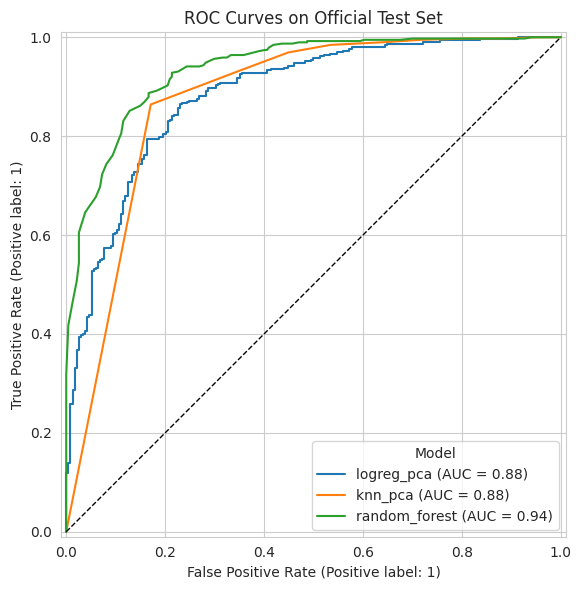

In [18]:
best_model_name = df_test_results.iloc[0]["name"]
print("Best model on test ROC-AUC:", best_model_name)

plt.figure(figsize=(7, 6))
for name, model in tuned_models.items():
    RocCurveDisplay.from_predictions(
        y_test,
        test_outputs[name]["y_prob"],
        name=name,
        ax=plt.gca(),
    )
plt.title("ROC Curves on Official Test Set")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

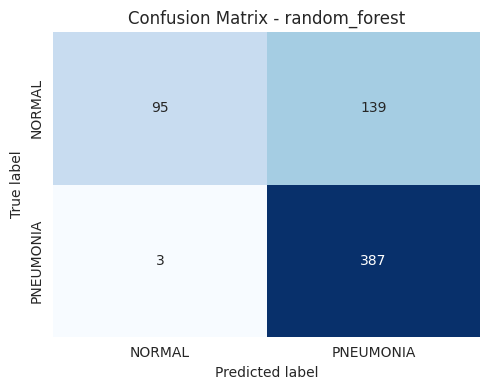

              precision    recall  f1-score   support

      NORMAL       0.97      0.41      0.57       234
   PNEUMONIA       0.74      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.70      0.71       624
weighted avg       0.82      0.77      0.74       624



In [19]:
cm = confusion_matrix(y_test, test_outputs[best_model_name]["y_pred"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_outputs[best_model_name]["y_pred"], target_names=CLASS_NAMES))

## 10. Save Trained Models

We persist tuned models so the notebook can be rerun without retraining from scratch.

In [20]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, model in tuned_models.items():
    out_path = MODELS_DIR / f"{name}_tuned.joblib"
    joblib.dump(model, out_path)
    print("Saved:", out_path)

best_model_path = MODELS_DIR / "best_model.joblib"
joblib.dump(tuned_models[best_model_name], best_model_path)
print("Saved best model:", best_model_path)

Saved: models/logreg_pca_tuned.joblib
Saved: models/knn_pca_tuned.joblib
Saved: models/random_forest_tuned.joblib
Saved best model: models/best_model.joblib


## 11. Answers to Research Questions

1. **Which classical algorithm performs best?**
   - Based on `df_test_results`, the best model is the one with highest test ROC-AUC (see `best_model_name`).

2. **Is cross-validation more reliable than a single split?**
   - Yes. CV reports mean and std over folds (`df_cv`), while simple split (`df_simple`) can be optimistic or pessimistic depending on one random partition.

3. **Did validation-based tuning help?**
   - Compare pre-tuning CV/simple split with tuned validation and final test results. In most cases, tuning improves ROC-AUC/F1, though gains depend on model family and parameter sensitivity.

### Final notes
- This pipeline is intentionally classical ML and computationally lightweight.
- Next improvement path: richer features or CNN-based transfer learning for stronger performance.